<a href="https://colab.research.google.com/github/bumsootead/Seoul_Subway_Analytics/blob/main/python_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")

CLEANED_DIR = Path("/content/")
OUTPUT_DIR = Path("outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

daily = pd.read_csv(r"/content/station_daily_wide.csv")

daily.head()

,service_date,source_year,line_name,station_code,station_name,day_of_week,is_weekday,is_weekend,month,year_month,alightings,boardings,total_activity,net_boarding
0,2024-01-01,2024,1호선,150,서울역,Monday,True,False,1,2024-01,31810,36085,67895,4275
1,2024-01-01,2024,1호선,151,시청,Monday,True,False,1,2024-01,9704,11029,20733,1325
2,2024-01-01,2024,1호선,152,종각,Monday,True,False,1,2024-01,13191,16379,29570,3188
3,2024-01-01,2024,1호선,153,종로3가,Monday,True,False,1,2024-01,11650,14309,25959,2659
4,2024-01-01,2024,1호선,154,종로5가,Monday,True,False,1,2024-01,10180,11200,21380,1020


# Hourly demand by weekday/weekend

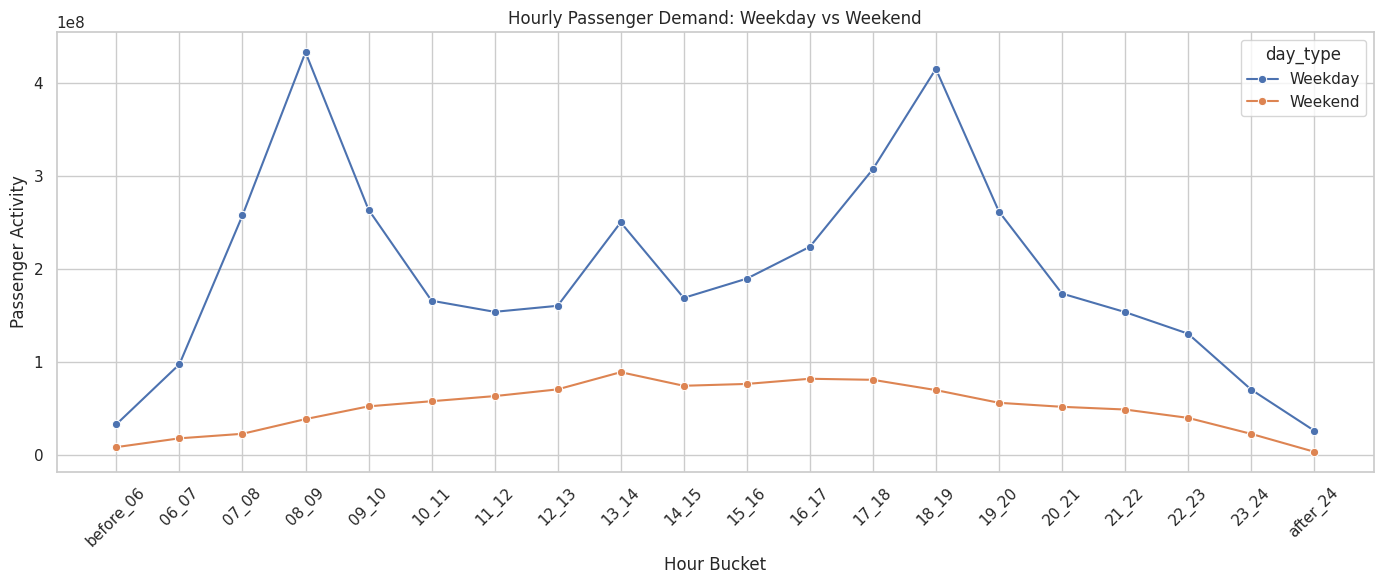

In [ ]:
hourly_total = pd.read_csv(
    CLEANED_DIR / "station_hourly_total.csv",
    encoding="utf-8-sig",
    usecols=[
        "service_date", "source_year", "line_name",
        "station_code", "station_name", "direction",
        "hour_bucket", "passenger_count", "is_weekday",
        "month"
    ],
    parse_dates=["service_date"]
)
hour_order = [
    "before_06", "06_07", "07_08", "08_09", "09_10",
    "10_11", "11_12", "12_13", "13_14", "14_15",
    "15_16", "16_17", "17_18", "18_19", "19_20",
    "20_21", "21_22", "22_23", "23_24", "after_24"
]

hourly_pattern = (
    hourly_total
    .groupby(["hour_bucket", "is_weekday"], as_index=False)
    ["passenger_count"]
    .sum()
)

hourly_pattern["hour_bucket"] = pd.Categorical(
    hourly_pattern["hour_bucket"],
    categories=hour_order,
    ordered=True
)

hourly_pattern = hourly_pattern.sort_values("hour_bucket")
hourly_pattern["day_type"] = hourly_pattern["is_weekday"].map(
    {True: "Weekday", False: "Weekend"}
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=hourly_pattern,
    x="hour_bucket",
    y="passenger_count",
    hue="day_type",
    marker="o"
)

plt.title("Hourly Passenger Demand: Weekday vs Weekend")
plt.xlabel("Hour Bucket")
plt.ylabel("Passenger Activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_hourly_weekday_weekend.png", dpi=300)
plt.show()

# Peak-time heatmap

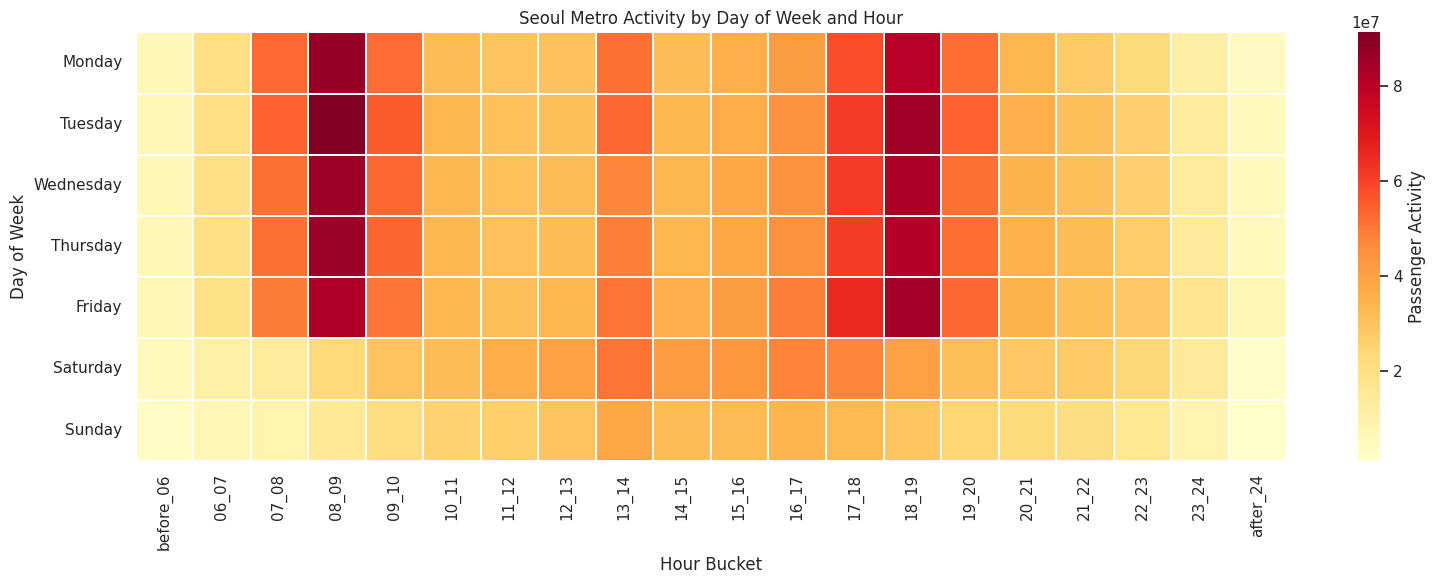

In [ ]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

hourly_total['day_of_week'] = hourly_total['service_date'].dt.day_name()

heatmap_data = (
    hourly_total.groupby(["day_of_week", "hour_bucket"])["passenger_count"]
    .sum()
    .reset_index()
)

heatmap_data["day_of_week"] = pd.Categorical(
    heatmap_data["day_of_week"],
    categories=day_order,
    ordered=True
)

heatmap_data["hour_bucket"] = pd.Categorical(
    heatmap_data["hour_bucket"],
    categories=hour_order,
    ordered=True
)

heatmap_matrix = heatmap_data.pivot(
    index="day_of_week",
    columns="hour_bucket",
    values="passenger_count"
)

plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_matrix,
    cmap="YlOrRd",
    linewidths=0.2,
    cbar_kws={"label": "Passenger Activity"}
)

plt.title("Seoul Metro Activity by Day of Week and Hour")
plt.xlabel("Hour Bucket")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_weekday_hour_heatmap.png", dpi=300)
plt.show()

# Commuter, residential, and commercial hub classification

In [ ]:
peak_hours = {
    "morning": ["06_07", "07_08", "08_09"],
    "evening": ["17_18", "18_19", "19_20"],
    "midday": ["10_11", "11_12", "12_13", "13_14", "14_15"]
}

weekday_hourly = hourly_total[
    hourly_total["is_weekday"]
].copy()

station_direction = (
    weekday_hourly
    .groupby(
        [
            "source_year", "line_name", "station_code",
            "station_name", "direction", "hour_bucket"
        ],
        as_index=False
    )["passenger_count"]
    .mean()
)

station_pivot = (
    station_direction
    .pivot_table(
        index=[
            "source_year", "line_name",
            "station_code", "station_name"
        ],
        columns=["direction", "hour_bucket"],
        values="passenger_count",
        fill_value=0
    )
)

In [ ]:
def get_direction_period(data, direction, hours):
    columns = [
        (direction, hour)
        for hour in hours
        if (direction, hour) in data.columns
    ]
    return data[columns].sum(axis=1)

station_profile = station_pivot.copy()

station_profile["morning_boardings"] = get_direction_period(
    station_profile, "board", peak_hours["morning"]
)

station_profile["morning_alightings"] = get_direction_period(
    station_profile, "alight", peak_hours["morning"]
)

station_profile["evening_boardings"] = get_direction_period(
    station_profile, "board", peak_hours["evening"]
)

station_profile["evening_alightings"] = get_direction_period(
    station_profile, "alight", peak_hours["evening"]
)

station_profile["midday_activity"] = (
    get_direction_period(station_profile, "board", peak_hours["midday"])
    + get_direction_period(station_profile, "alight", peak_hours["midday"])
)

station_profile["total_weekday_activity"] = station_profile.sum(
    axis=1,
    numeric_only=True
)

station_profile["morning_net_alighting"] = (
    station_profile["morning_alightings"]
    - station_profile["morning_boardings"]
)

station_profile["evening_net_boarding"] = (
    station_profile["evening_boardings"]
    - station_profile["evening_alightings"]
)

station_profile["midday_share"] = (
    station_profile["midday_activity"]
    / station_profile["total_weekday_activity"]
)

station_profile = station_profile.reset_index()

# Classify Stations

In [ ]:
high_volume_cutoff = station_profile[
    "total_weekday_activity"
].quantile(0.75)

commercial_cutoff = station_profile[
    "midday_share"
].quantile(0.75)

def classify_station(row):
    # Retrieve values. They should be scalar. If they are Series of length 1, .item() extracts the scalar.
    # If they are already scalar, .item() will raise an AttributeError, so we check type.
    morning_net_alighting_val = row["morning_net_alighting"]
    evening_net_boarding_val = row["evening_net_boarding"]
    total_weekday_activity_val = row["total_weekday_activity"]
    midday_share_val = row["midday_share"]

    # Convert to scalar if it's a pandas Series of length 1
    import pandas as pd
    if isinstance(morning_net_alighting_val, pd.Series):
        morning_net_alighting_val = morning_net_alighting_val.item()
    if isinstance(evening_net_boarding_val, pd.Series):
        evening_net_boarding_val = evening_net_boarding_val.item()
    if isinstance(total_weekday_activity_val, pd.Series):
        total_weekday_activity_val = total_weekday_activity_val.item()
    if isinstance(midday_share_val, pd.Series):
        midday_share_val = midday_share_val.item()

    if (
        morning_net_alighting_val > 0
        and evening_net_boarding_val > 0
        and total_weekday_activity_val >= high_volume_cutoff
    ):
        return "Commuter / employment hub"

    if (
        morning_net_alighting_val < 0
        and evening_net_boarding_val < 0
        and total_weekday_activity_val >= high_volume_cutoff
    ):
        return "Residential origin hub"

    if midday_share_val >= commercial_cutoff:
        return "Commercial / leisure hub"

    return "Local / balanced station"

station_profile["station_function"] = station_profile.apply(
    classify_station,
    axis=1
)

# Create the key scatterplot

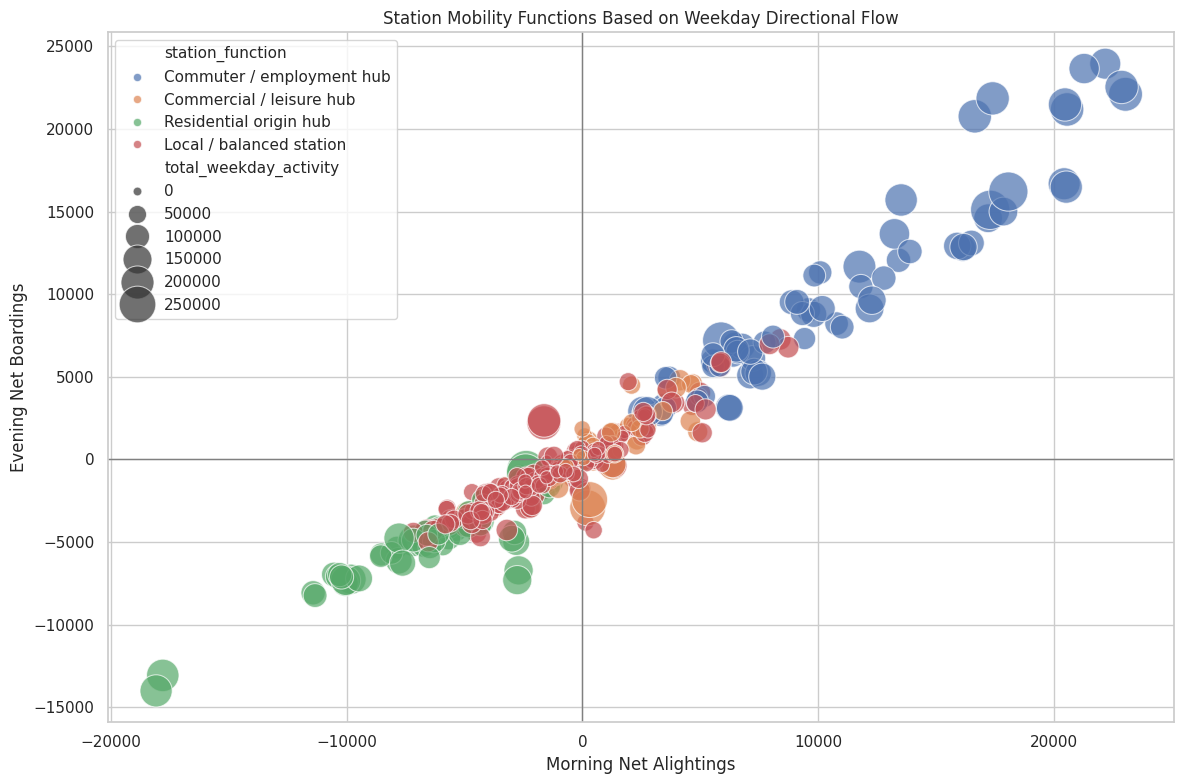

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=station_profile,
    x="morning_net_alighting",
    y="evening_net_boarding",
    size="total_weekday_activity",
    hue="station_function",
    sizes=(40, 800),
    alpha=0.7
)

plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)

plt.title("Station Mobility Functions Based on Weekday Directional Flow")
plt.xlabel("Morning Net Alightings")
plt.ylabel("Evening Net Boardings")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_station_function_scatter.png", dpi=300)
plt.show()